Dataset Shape: (2200, 8)

First 5 Rows:
    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice

Missing Values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

Crop Classes:
['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']

Accuracy: 99.32 %

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        23
  

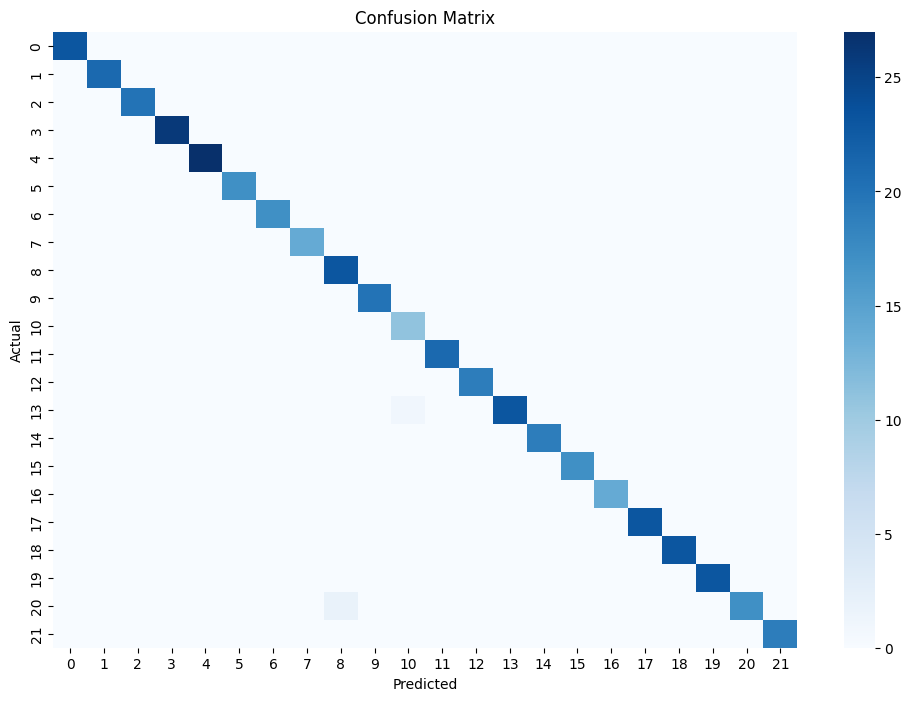

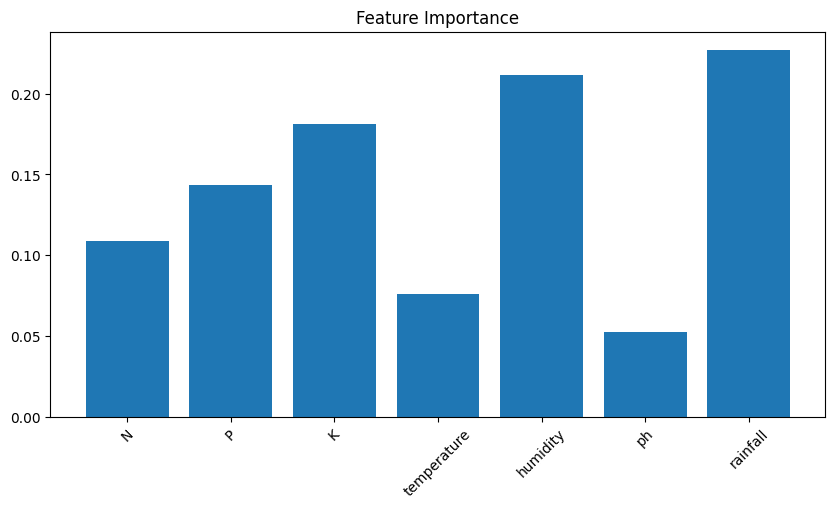

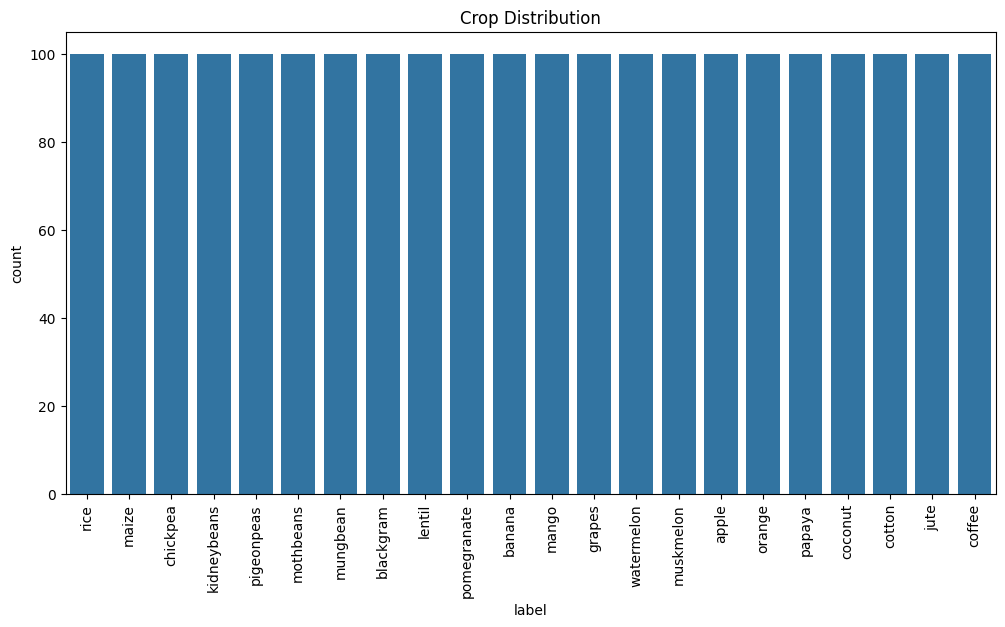

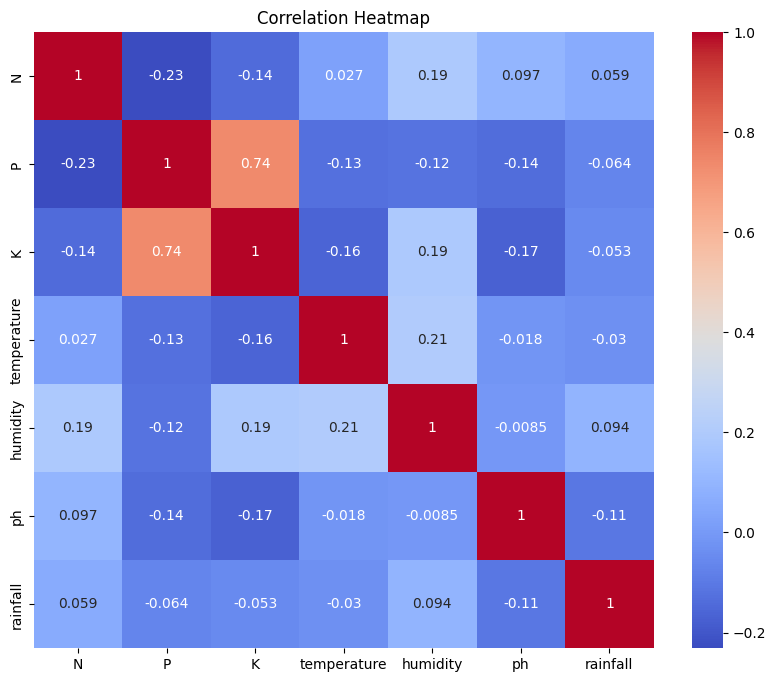


Recommended Crop: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# ==========================================
# CROP RECOMMENDATION SYSTEM
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("Crop_recommendation.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# CHECK DATASET
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())

print("\nCrop Classes:")
print(df['label'].unique())

# ==========================================
# FEATURES & TARGET
# ==========================================

X = df.drop("label", axis=1)

y = df["label"]

# ==========================================
# ENCODE LABELS
# ==========================================

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(y)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

# ==========================================
# RANDOM FOREST MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

pred = model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("\nAccuracy:", round(accuracy*100,2), "%")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================
# FEATURE IMPORTANCE
# ==========================================

importance = model.feature_importances_

feature_names = X.columns

plt.figure(figsize=(10,5))

plt.bar(
    feature_names,
    importance
)

plt.title("Feature Importance")

plt.xticks(rotation=45)

plt.show()

# ==========================================
# CROP DISTRIBUTION
# ==========================================

plt.figure(figsize=(12,6))

sns.countplot(
    x=df["label"]
)

plt.title("Crop Distribution")

plt.xticks(rotation=90)

plt.show()

# ==========================================
# CORRELATION HEATMAP
# ==========================================

plt.figure(figsize=(10,8))

sns.heatmap(
    df.drop("label", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================
# SAMPLE PREDICTION
# ==========================================

sample = [[90,42,43,20.8,82,6.5,203]]

prediction = model.predict(sample)

crop = encoder.inverse_transform(prediction)

print("\nRecommended Crop:", crop[0])

In [ ]:
print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 99.32 %
